<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
      Spam Classification-NLP (Natural Language Processing)
</center></p></h1>

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Libraries
 </font><br>
 <br>   
<br>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score



<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [4]:
# read dataset (csv -> pandas dataframe)
df = pd.read_csv(r"D:\Data Analysis- Scientist\Projects\Biga Data & NLP\Spam_text_message\SPAM text message 20170820 - Data.csv")
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [5]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [6]:
df.value_counts()

Category  Message                                                                                                                                                
ham       Sorry, I'll call later                                                                                                                                     30
          I cant pick the phone right now. Pls send a message                                                                                                        12
          Ok...                                                                                                                                                      10
          Okie                                                                                                                                                        4
          7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st "Ur Lovely Friendship"... good morning dear     

  category  number
0     spam       0
1      ham       0


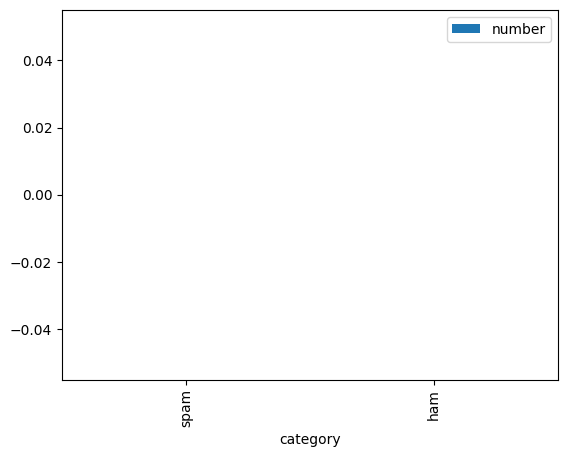

In [8]:
# gain insight from data
data = {'category': ['spam', 'ham'],
        'number': [len(df.loc[df.Category==1]), len(df.loc[df.Category==0])]
        }  
df_count = pd.DataFrame(data,columns=['category', 'number'])
print (df_count)

df_count.plot(x ='category', y='number', kind = 'bar')
plt.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Text Preprocessing 
</center></p></h1>

In [9]:
# cleaning dataset
stemmer = PorterStemmer()
corpus = []

for w in range(len(df['Message'])):
    msg = df['Message'][w]
    msg = re.sub("[^a-zA-Z]", " ", msg)
    msg = msg.lower()
    msg = msg.split()
    msg = [stemmer.stem(word) for word in msg if not word in set(stopwords.words('english'))]
    msg = " ".join(msg)
    corpus.append(msg)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Labeling
</center></p></h1>

In [12]:
df["Category"].replace({'ham': 0 ,'spam': 1}, inplace=True)
print(df.head(10))

   Category                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...
5         1  FreeMsg Hey there darling it's been 3 week's n...
6         0  Even my brother is not like to speak with me. ...
7         0  As per your request 'Melle Melle (Oru Minnamin...
8         1  WINNER!! As a valued network customer you have...
9         1  Had your mobile 11 months or more? U R entitle...


C:\Users\Amir\AppData\Local\Temp\ipykernel_2208\836395475.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Category"].replace({'ham': 0 ,'spam': 1}, inplace=True)
C:\Users\Amir\AppData\Local\Temp\ipykernel_2208\836395475.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Category"].repla

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     create word vector
</center></p></h1>

In [13]:
tf = TfidfVectorizer()
tf.fit(corpus)
# print(tf.vocabulary_)
X = tf.transform(corpus).toarray()

Y = df['Category']

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Split/Test
</center></p></h1>

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20, random_state = 0)


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    ML MODELING
</center></p></h1>

In [15]:
model = MultinomialNB().fit(X_train, y_train)

y_pred = model.predict(X_test)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
   Evaluation
   
</center></p></h1>

In [16]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

[[955   0]
 [ 34 126]]


In [17]:
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)

In [18]:
print("acc", acc, "\n")
print("prec", prec, "\n")
print("rec", rec, "\n")

acc 0.9695067264573991 

prec 1.0 

rec 0.7875 

